In [1]:
# Core Python imports
import os
import datetime
import functools
import warnings
warnings.filterwarnings("ignore",message="In a future version of xarray the default value for join",category=FutureWarning)
warnings.filterwarnings("ignore",message="In a future version of xarray the default value for compat",category=FutureWarning)
warnings.filterwarnings("ignore",message="Data requested at a higher resolution than available")
warnings.filterwarnings("ignore",message="Importing `spectral_angle_mapper` from `torchmetrics.functional`",category=FutureWarning)
# Scientific standard imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# PyEarthTools imports including NCI cached data
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
from pyearthtools.data.time import Petdt

my_site = 'site_archive_nci'  # set this to 'site_archive_nci', 'site_archive_jasmin' or 'site_archive_met_office'
import importlib
_ = importlib.import_module(my_site)

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Set random seed for reproducibility
torch.manual_seed(42)

# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Detected device {device}, will attempt to use for training")

Detected device cuda:0, will attempt to use for training


In [2]:
# We specify the date, hour, and minute for querying data
date = '20200105T0000'
start_date = '20200101T00'
end_date = '20210101T00'
sat_timestep = '10 minutes'
bar_timestep = "1 hour" 

In [3]:
n_prior_sat = 12
n_prior_bar = n_prior_sat // 6
n_post = 1

# Objective
This data loader is for a "nowcasting" model, so it needs to read in N number of satellite images prior to the forecast time (I am using 12 images x 10 min resolution = 2 hours of data), and then forecast the next image (can forecase multiple, but focussing on one here). This is simple enough for a single dataset using petpipe.modifications.TemporalWindow, as shown in the PET tutorials.

The added complexity is that we want to add data from a physical model (here I am using BARRA) as additional inputs to the nowcasting model, to see if it helps the forecast. Again, the task of blending datasets is straight forwards when you are working with a single timestep, and is also clearly demonstrated in a PET tutorial. The difficult part is loading a 2 hour window of data, AND interpolate BARRA to the same temporal/spatial resolution as Himawari.

One solution, which looks good at first, is to use a Himawari sample and interplike operation. This successfully loads the correct data, and performs the interpolation, but requires the Himawari to move with the iterator, i.e. the sample needs to be for the exact times you are trying to load.

The current working solution is to load each dataset into memory separately, then use xarray to do interpolation.

# Himawari

In [9]:
himawar_vars = [
    'surface_global_irradiance',
    # 'solar_elevation'
]
himawari = petdata.archive.Himawari(himawar_vars)

# wide window to account for edges needed for interpolation
temporal_window_sat = petpipe.modifications.TemporalWindow(
    prior_indexes=[i for i in range(-n_prior_sat - 1, 0)],
    posterior_indexes=[i for i in range(0, n_post + 1)],
    merge_method = functools.partial(xr.concat, dim='time'),
    timedelta=petdata.time.TimeDelta((10, "minutes"))
)
sat_pipe = petpipe.Pipeline(
    himawari,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  #
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),
    petdata.transform.region.Bounding(-35, -28.5, 145, 151.5),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(1200),
    temporal_window_sat,
    petpipe.operations.xarray.Merge(),
    # iterator=petpipe.iterators.DateRange(start_date, end_date, interval=sat_timestep),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

# BARRA

In [10]:
barra_convective_vars = [
    "RH24mean"
]
barra_conv = petdata.archive.BARRA_V2(barra_convective_vars, domain_id='AUST-11', frequency='1hr')

# wide window to account for edges needed for interpolation, and for BARRA low resolution
temporal_window_bar = petpipe.modifications.TemporalWindow(
    prior_indexes=[i for i in range(-n_prior_bar - 1, 0)],
    posterior_indexes=[i for i in range(0, n_post + 1)],
    merge_method = functools.partial(xr.concat, dim='time'),
    timedelta=petdata.time.TimeDelta((1, "h"))
)

bar_pipe = petpipe.Pipeline(
    barra_conv,
    petdata.transforms.coordinates.Drop("crs"),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),
    petdata.transform.region.Bounding(-35, -28.5, 145, 151.5),  # cut down on region for example
    petpipe.operations.xarray.normalisation.SingleValueDivision(100),
    temporal_window_bar,
    petpipe.operations.xarray.Merge(),
    # iterator=petpipe.iterators.DateRange(start_date, end_date, interval=bar_timestep),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)

# Merging

In [25]:
full_pipe = petpipe.Pipeline(
    (sat_pipe, bar_pipe),
    iterator=petpipe.iterators.DateRange(start_date, end_date, interval=sat_timestep),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)
full_iterator = iter(full_pipe)
sat_sample, bar_sample = next(full_iterator)

/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(


In [26]:
sat_sample, bar_sample = next(full_iterator)
sat_sample, bar_sample = next(full_iterator)

/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/opt/conda/envs/pet/lib/python3.12/site-packages/pyearthtools/data/indexes/_indexes.py:789: IndexWarning: Data requested at a higher resolution than available. minute > hour
  warnings.warn(
/opt/conda/envs/pet/lib/python3.12/site-packa

In [13]:
bar_interp = bar_sample.interp(
    latitude=sat_sample.latitude,
    longitude=sat_sample.longitude,
    time=sat_sample.time,
    method='nearest'
)

In [14]:
combined = xr.merge([bar_interp, sat_sample])

In [15]:
combined.isel(time=slice(1, -1)).time.values

array(['2019-12-31T22:20:00.000000000', '2019-12-31T22:30:00.000000000',
       '2019-12-31T22:40:00.000000000', '2019-12-31T22:50:00.000000000',
       '2019-12-31T23:00:00.000000000', '2019-12-31T23:10:00.000000000',
       '2019-12-31T23:20:00.000000000', '2019-12-31T23:30:00.000000000',
       '2019-12-31T23:40:00.000000000', '2019-12-31T23:50:00.000000000',
       '2020-01-01T00:00:00.000000000', '2020-01-01T00:10:00.000000000',
       '2020-01-01T00:20:00.000000000'], dtype='datetime64[ns]')

In [16]:
# Trim the edges to remove NANs from interpolation (256 square region)
combined_inner = combined.isel(
    time=slice(1, -1),
    latitude=slice(10, 266),
    longitude=slice(10, 236),
)

0


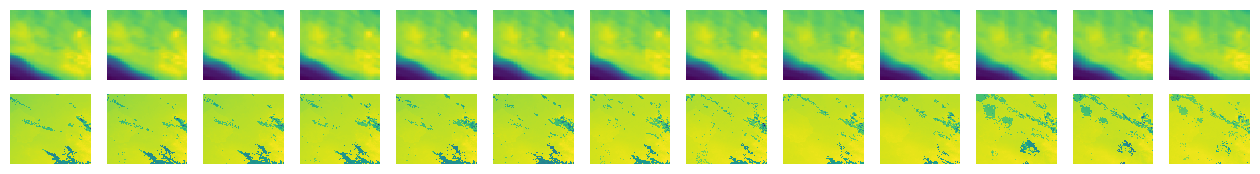

In [17]:
fig, ax = plt.subplots(nrows=2, ncols=13, figsize=(16,2))
n_nans = 0
for i, var in enumerate(combined_inner.data_vars):
    for j, time in enumerate(combined_inner.time):
        combined_inner[var].sel(time=time).plot(ax=ax[i,j], add_colorbar=False)
        n_nans += combined_inner[var].sel(time=time).isnull().sum().compute().item()
        ax[i,j].set_axis_off()
        ax[i,j].set_title(None)
print(n_nans)

In [18]:
arr = np.stack([combined_inner[v].values for v in combined_inner.data_vars], axis=0)  # (c, t, h, w)

# Rearrange c t h w -> t c h w
arr = np.transpose(arr, (1, 0, 2, 3))  # (t, c, h, w)

In [27]:
full_pipe["20200101T1130"]

DataNotFoundError: Data with args: (Petdt('2020-01-01T11:40'),) could not be found.